In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
membership = pd.read_excel("Dataset/Membership.xlsx")
movie_master = pd.read_excel("Dataset/Movie_Master.xlsx")
user_mapping = pd.read_excel("Dataset/User_Mapping.xlsx")
view_history = pd.read_excel("Dataset/View_History.xlsx")

> Membership과 User_Mapping의 USER_KEY 대응하기

1. Membership의 "user_no" → "USER_KEY"
2. User_Mapping의 "uid" → "USER_KEY"

In [3]:
membership.rename(columns={"user_no" : "USER_KEY"}, inplace=True)
user_mapping.rename(columns={"uid" : "USER_KEY"}, inplace=True)

> User_Mapping과 View_History의 USER_NUM 대응하기

1. User_Mapping의 "USER_ID" → "USER_NUM"
2. View_History의 "USER_ID" → "USER_NUM"

In [4]:
user_mapping.rename(columns={"USER_ID" : "USER_NUM"}, inplace=True)
view_history.rename(columns={"USER_ID" : "USER_NUM"}, inplace=True)

> Membership에서 concurrent_streams에 따라 plan 컬럼 생성, 대응되는 플랜 삽입

사용하는 함수: .map()

concurrent_streams → 1, plan = "Basic"  
concurrent_streams → 2, plan = "Standard"  
concurrent_streams → 4, plan = "Premium"  

In [5]:
membership["concurrent_streams"] = pd.to_numeric(membership["concurrent_streams"], errors="coerce")
membership["plan"] = membership["concurrent_streams"].map({
    1: "Basic",
    2: "Standard",
    4: "Premium"
}).fillna("")


> EDA1. 각 Plan별로 결제금액(Amount)의 분포 알아보기

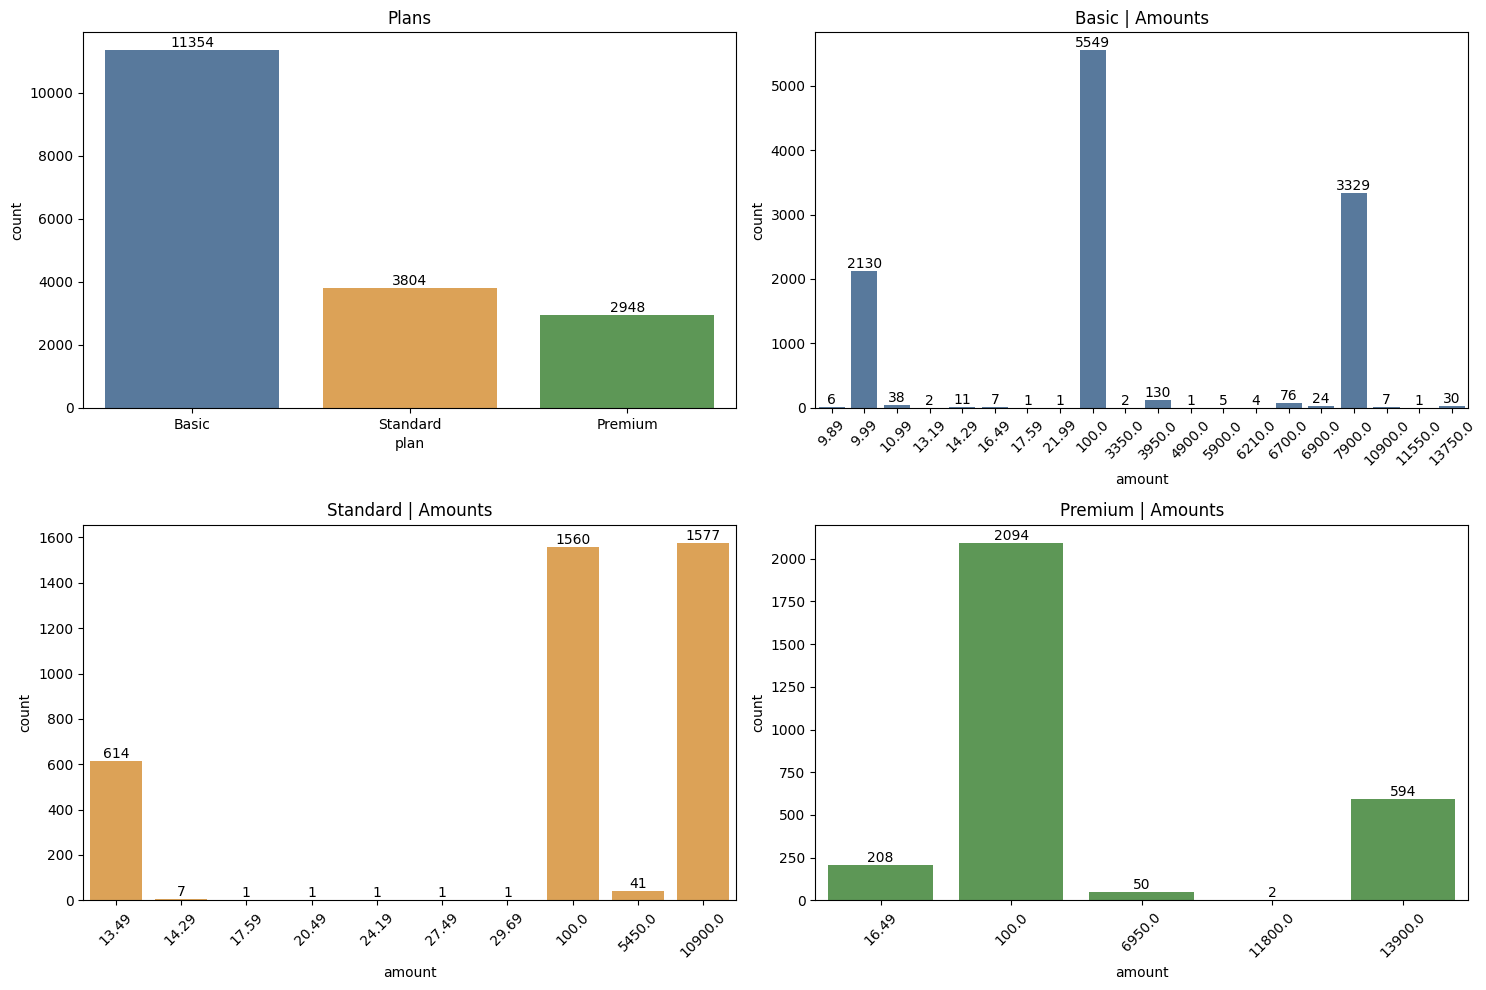

In [6]:
plan_palette = {"Basic": "#4C78A8", "Standard": "#F2A541", "Premium": "#54A24B"}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=membership, x="plan", hue="plan", ax=axes[0][0], palette=plan_palette, order=["Basic", "Standard", "Premium"])
axes[0][0].set_title("Plans")
for container in axes[0][0].containers:
    axes[0][0].bar_label(container)

sns.countplot(data=membership[membership["plan"] == "Basic"], x="amount", ax=axes[0][1], color=plan_palette["Basic"])
axes[0][1].set_title("Basic | Amounts")
axes[0][1].tick_params(axis="x", labelrotation=45)
for container in axes[0][1].containers:
    axes[0][1].bar_label(container)

sns.countplot(data=membership[membership["plan"] == "Standard"], x="amount", ax=axes[1][0], color=plan_palette["Standard"])
axes[1][0].set_title("Standard | Amounts")
axes[1][0].tick_params(axis="x", labelrotation=45)
for container in axes[1][0].containers:
    axes[1][0].bar_label(container)

sns.countplot( data=membership[membership["plan"] == "Premium"], x="amount", ax=axes[1][1], color=plan_palette["Premium"])
axes[1][1].set_title("Premium | Amounts")
axes[1][1].tick_params(axis="x", labelrotation=45)
for container in axes[1][1].containers:
    axes[1][1].bar_label(container)

plt.tight_layout()

> Explain01. amount별로 count 집계, 그리고 각 amount의 추정 plan을 기입한 excel

In [ ]:
Explain01_amount_count = membership["amount"].value_counts().reset_index()
Explain01_amount_count.columns = ["amount", "count"]
Explain01_amount_count["추정 요금제"] = ""
Explain01_amount_count["비고"] = ""
# Explain01_amount_count.to_excel("Dataset/_Explain01_amount_count.xlsx", index=False)

> 이제는 못 참겠다, 그냥 이상치 날려버리자.

> EDA 2. concurrent_streams가 3이나 NaN이 전체에서 몇 퍼센트를 차지하는가?

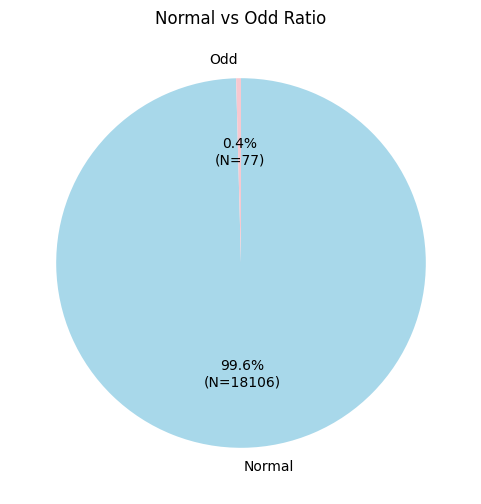

In [8]:
import matplotlib.pyplot as plt

mask = membership["concurrent_streams"].isin([1, 2, 4])

normal = membership[mask]
odd = membership[~mask]

sizes = [len(normal), len(odd)]
labels = ["Normal", "Odd"]
colors = ["#A8D8EA", "#F7C8D0"]  # 파스텔 블루, 파스텔 핑크

def autopct_with_count(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(N={count})"
    return inner

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=autopct_with_count(sizes),
    startangle=90,
    counterclock=False
)
plt.title("Normal vs Odd Ratio")
plt.show()


> Concurrent_streams가 3이거나 NaN인 77개의 행을 날려버렸음.  
- Outlier_Removed_01_Membership.xlsx로 저장

In [12]:
removed_odd = odd.copy()
Outlier_Removed_01_Membership = membership[membership["concurrent_streams"].isin([1, 2, 4])].copy()
Outlier_Removed_01_Membership["concurrent_streams"].value_counts(dropna=False).sort_index()
Outlier_Removed_01_Membership.to_excel("Dataset/_Outlier_Removed_01_Membership.xlsx")

> 이제 Membership과 User_Mapping을 merge Join 해볼까

In [14]:
display(
	Outlier_Removed_01_Membership.head(),
	user_mapping.head()
)

,USER_KEY,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,plan
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.00,134,4.0,O,NaN,NaN,pc,Y,F,20.0,2021-03-14,20,2021-04-14,Premium
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.00,190,1.0,O,O,NaN,pc,Y,F,25.0,2021-03-09,14,2021-04-09,Basic
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.00,132,1.0,O,NaN,NaN,android,NaN,F,55.0,2021-03-09,22,2021-04-09,Basic
3,445fb8813626d3d49b94b5be58cd76d80ed31fa94f8372...,pk_1508,9.99,140,1.0,NaN,NaN,O,ios,N,N,40.0,2021-03-09,10,2021-04-10,Basic
4,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.00,180,2.0,O,NaN,O,android,N,F,20.0,2021-03-09,2,2021-04-09,Standard


,USER_KEY,USER_NUM
0,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,0
1,a314c8a65b0fd91e1889c1debaa21e5bb6330560ee9721...,1
2,6652e2597875d4f34b48a0610c035521f2aea2f8abc5f3...,2
3,873fb3eddac14ca6123810dd72a4195915afacaaecb073...,3
4,8668c3dfce041e29bc5b80fe33fb8754718587a7537db1...,4


> 1단계. membership과 user_mapping의 중복 확인

In [17]:
print("membership 행 수:", len(membership))
print("user_mapping 행 수:", len(user_mapping))


print("membership USER_KEY 중복 수:", membership["USER_KEY"].duplicated().sum())
print("user_mapping USER_KEY 중복 수:", user_mapping["USER_KEY"].duplicated().sum())


membership 행 수: 18183
user_mapping 행 수: 19877
membership USER_KEY 중복 수: 338
user_mapping USER_KEY 중복 수: 49


> 2단계. left merge하기

In [20]:
membership_with_usernum = Outlier_Removed_01_Membership.merge(
    user_mapping[["USER_KEY", "USER_NUM"]],
    on="USER_KEY",
    how="left"
)
display(membership_with_usernum)

,USER_KEY,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,plan,USER_NUM
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.00,134,4.0,O,NaN,NaN,pc,Y,F,20.0,2021-03-14,20,2021-04-14,Premium,2342
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.00,190,1.0,O,O,NaN,pc,Y,F,25.0,2021-03-09,14,2021-04-09,Basic,17323
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.00,132,1.0,O,NaN,NaN,android,NaN,F,55.0,2021-03-09,22,2021-04-09,Basic,14848
3,445fb8813626d3d49b94b5be58cd76d80ed31fa94f8372...,pk_1508,9.99,140,1.0,NaN,NaN,O,ios,N,N,40.0,2021-03-09,10,2021-04-10,Basic,1101
4,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.00,180,2.0,O,NaN,O,android,N,F,20.0,2021-03-09,2,2021-04-09,Standard,18313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18208,19e652cf637d87e21620439712da1e73625ab531a5d8d7...,pk_1487,100.00,134,1.0,O,NaN,NaN,pc,NaN,F,20.0,2021-03-07,13,2021-04-07,Basic,15004
18209,281a9090fcb3cbcf4b84fe9d5d7ebeefcce20b182be2db...,pk_2025,100.00,151,1.0,O,NaN,O,android,Y,F,30.0,2021-03-07,21,2021-04-07,Basic,4556
18210,9601965f563806966a1cc1c119fd34bcbf577f32d3b145...,pk_1488,100.00,180,2.0,O,NaN,O,pc,Y,F,20.0,2021-03-10,22,2021-04-10,Standard,14413
18211,8a68791bfacbaa97269b6aec36a519c54f1efa28a35981...,pk_1488,10900.00,134,2.0,NaN,NaN,NaN,mobile,NaN,NaN,NaN,2021-03-03,18,2021-03-08,Standard,8758


> 3. USER_KEY 하나가 여러 USER_NUM을 가지는가?

In [32]:
print("USER_KEY 중복 수:", membership_with_usernum["USER_KEY"].duplicated().sum())
print("USER_NUM 중복 수:", membership_with_usernum["USER_NUM"].duplicated().sum())

USER_KEY 중복 수: 420
USER_NUM 중복 수: 377


> EDA 4. Membership과 User_Mapping의 중복 구조 점검

이번 점검의 목적은 `membership_with_usernum`에서 관측된 `USER_KEY`, `USER_NUM` 중복이 단순 오류인지, 아니면 정상적인 멤버십 이력 구조인지 구분하는 것이다.

잠정 결론은 다음과 같다.

1. `Membership`은 유저 마스터 테이블보다 `멤버십 이력` 또는 `구독 상태 변경 기록`에 더 가깝다.
2. 중복 `USER_KEY`의 다수는 짧은 구독 기간, 종료일과 다음 시작일의 인접 또는 중첩, 경계 시점의 플랜 변경 패턴을 동반한다.
3. 따라서 `Membership` 내부의 `USER_KEY` 중복은 우선 정상적인 이력으로 보존하는 것이 타당하다.
4. 반면 `User_Mapping`에서는 일부 `USER_KEY`가 여러 `USER_NUM`과 연결되어 있으므로, 이 구간은 별도 점검 대상으로 남겨 둔다.
5. 현 단계에서는 `Membership`의 중복 `USER_KEY`를 제거하지 않고 유지하되, 이후 유저 단위 분석이 필요할 때 별도의 집계 테이블을 만드는 방향이 적절하다.

In [33]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

membership_base = Outlier_Removed_01_Membership.copy()
membership_base["plan"] = membership_base["concurrent_streams"].map({1: "Basic", 2: "Standard", 4: "Premium"})

membership_userkey_counts = membership_base["USER_KEY"].value_counts()
duplicated_userkeys = membership_userkey_counts[membership_userkey_counts > 1].index

mapping_usernum_counts = user_mapping.groupby("USER_KEY")["USER_NUM"].nunique()
mapping_multi_userkeys = mapping_usernum_counts[mapping_usernum_counts > 1]
mapping_multi_userkeys_in_membership = mapping_multi_userkeys[mapping_multi_userkeys.index.isin(membership_base["USER_KEY"])]

membership_diagnosis_summary = pd.DataFrame({
    "항목": [
        "Membership 전체 행 수",
        "Membership 고유 USER_KEY 수",
        "Membership 중복 USER_KEY 행 수",
        "Membership 중복 USER_KEY 수",
        "User_Mapping 다중 USER_NUM USER_KEY 수",
        "Membership과 겹치는 다중 매핑 USER_KEY 수",
        "Merge 이후 증가한 행 수"
    ],
    "값": [
        len(membership_base),
        membership_base["USER_KEY"].nunique(),
        membership_base["USER_KEY"].duplicated().sum(),
        len(duplicated_userkeys),
        len(mapping_multi_userkeys),
        len(mapping_multi_userkeys_in_membership),
        len(membership_with_usernum) - len(membership_base)
    ]
})

pattern_rows = []

for user_key in duplicated_userkeys:
    temp = membership_base[membership_base["USER_KEY"] == user_key].sort_values(["reg_date", "end_date", "product_cd"]).copy()
    temp["duration_days"] = (temp["end_date"] - temp["reg_date"]).dt.days

    has_short_term = (temp["duration_days"] <= 2).any()
    has_overlap_or_touch = False
    has_plan_switch_near_boundary = False

    for idx in range(len(temp) - 1):
        gap = (temp.iloc[idx + 1]["reg_date"] - temp.iloc[idx]["end_date"]).days

        if gap <= 0:
            has_overlap_or_touch = True

        if -1 <= gap <= 1 and temp.iloc[idx]["plan"] != temp.iloc[idx + 1]["plan"]:
            has_plan_switch_near_boundary = True

    pattern_rows.append({
        "USER_KEY": user_key,
        "rows": len(temp),
        "has_short_term": has_short_term,
        "has_overlap_or_touch": has_overlap_or_touch,
        "has_plan_switch_near_boundary": has_plan_switch_near_boundary
    })

duplicate_userkey_pattern = pd.DataFrame(pattern_rows)

duplicate_pattern_summary = pd.DataFrame({
    "항목": [
        "2일 이하 구독 이력 존재",
        "종료일과 다음 시작일이 인접 또는 중첩",
        "경계 시점 플랜 변경 존재"
    ],
    "건수": [
        duplicate_userkey_pattern["has_short_term"].sum(),
        duplicate_userkey_pattern["has_overlap_or_touch"].sum(),
        duplicate_userkey_pattern["has_plan_switch_near_boundary"].sum()
    ]
})
duplicate_pattern_summary["비율"] = duplicate_pattern_summary["건수"] / len(duplicate_userkey_pattern)

display(membership_diagnosis_summary)
display(duplicate_pattern_summary)


,항목,값
0,Membership 전체 행 수,18106
1,Membership 고유 USER_KEY 수,17793
2,Membership 중복 USER_KEY 행 수,313
3,Membership 중복 USER_KEY 수,277
4,User_Mapping 다중 USER_NUM USER_KEY 수,48
5,Membership과 겹치는 다중 매핑 USER_KEY 수,42
6,Merge 이후 증가한 행 수,107


,항목,건수,비율
0,2일 이하 구독 이력 존재,211,0.761733
1,종료일과 다음 시작일이 인접 또는 중첩,260,0.938628
2,경계 시점 플랜 변경 존재,203,0.732852


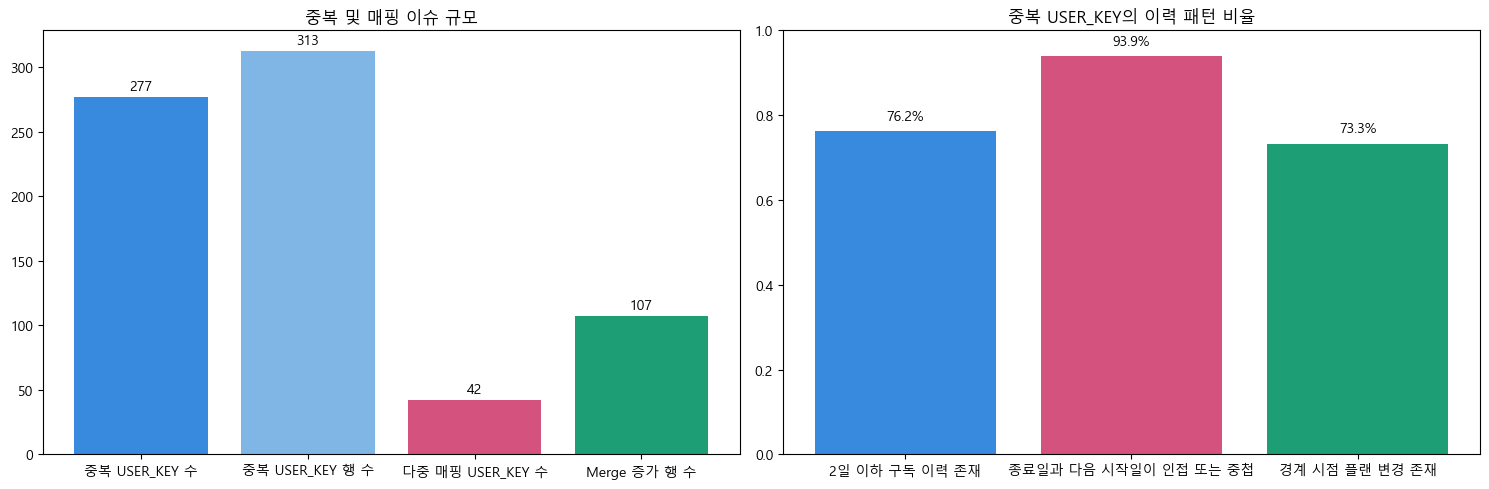

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

left_labels = [
    "중복 USER_KEY 수",
    "중복 USER_KEY 행 수",
    "다중 매핑 USER_KEY 수",
    "Merge 증가 행 수"
]
left_values = [
    len(duplicated_userkeys),
    membership_base["USER_KEY"].duplicated().sum(),
    len(mapping_multi_userkeys_in_membership),
    len(membership_with_usernum) - len(membership_base)
]

axes[0].bar(left_labels, left_values, color=["#378ADD", "#7FB6E6", "#D4537E", "#1D9E75"])
axes[0].set_title("중복 및 매핑 이슈 규모")
axes[0].tick_params(axis="x")

for idx, value in enumerate(left_values):
    axes[0].text(idx, value + 3, f"{value}", ha="center", va="bottom")

axes[1].bar(duplicate_pattern_summary["항목"], duplicate_pattern_summary["비율"], color=["#378ADD", "#D4537E", "#1D9E75"])
axes[1].set_title("중복 USER_KEY의 이력 패턴 비율")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x")

for idx, value in enumerate(duplicate_pattern_summary["비율"]):
    axes[1].text(idx, value + 0.02, f"{value:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [36]:
suspicious_userkeys = duplicate_userkey_pattern[
    duplicate_userkey_pattern["has_plan_switch_near_boundary"]
].sort_values(["rows", "has_short_term"], ascending=False)["USER_KEY"].head(5)

representative_histories = membership_base[
    membership_base["USER_KEY"].isin(suspicious_userkeys)
][["USER_KEY", "product_cd", "plan", "amount", "reg_date", "end_date"]].sort_values(["USER_KEY", "reg_date", "end_date", "product_cd"])

display(representative_histories)


,USER_KEY,product_cd,plan,amount,reg_date,end_date
16442,1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a8612...,pk_1487,Basic,7900.00,2021-03-05,2021-03-05
3351,1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a8612...,pk_1488,Standard,10900.00,2021-03-05,2021-03-05
9213,1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a8612...,pk_1489,Premium,13900.00,2021-03-05,2021-03-05
15388,1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a8612...,pk_2025,Basic,7900.00,2021-03-05,2021-03-05
9453,1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a8612...,pk_2026,Standard,10900.00,2021-03-05,2021-03-05
5564,1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a8612...,pk_2027,Premium,13900.00,2021-03-05,2021-03-05
16413,30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...,pk_1488,Standard,10900.00,2021-03-02,2021-03-03
15589,30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...,pk_1487,Basic,7900.00,2021-03-03,2021-03-04
8171,30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...,pk_1488,Standard,10900.00,2021-03-04,2021-03-06
15955,30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...,pk_1487,Basic,7900.00,2021-03-06,2021-03-07
